#  Veridi Logistics — "Last Mile" Delivery Auditor

**Dataset:** Olist Brazilian E-Commerce  
**Goal:** Audit delivery performance and correlate late deliveries with customer sentiment.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print(' Imports OK')

 Imports OK


---
## Story 1: The Schema Builder
Join Orders + Reviews + Customers into one master table without duplicating rows.

In [6]:
orders      = pd.read_csv('olist_orders_dataset.csv')
reviews     = pd.read_csv('olist_order_reviews_dataset.csv')
customers   = pd.read_csv('olist_customers_dataset.csv')
products    = pd.read_csv('olist_products_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
translations = pd.read_csv('product_category_name_translation.csv')

print('Orders:     ', orders.shape)
print('Reviews:    ', reviews.shape)
print('Customers:  ', customers.shape)
print('Products:   ', products.shape)
print('Order Items:', order_items.shape)

Orders:      (99441, 8)
Reviews:     (99224, 7)
Customers:   (99441, 5)
Products:    (32951, 9)
Order Items: (112650, 7)


In [7]:
# Reviews have a 1-to-many relationship with orders (multiple reviews per order is rare but exists).
# Keep only the most recent review per order to avoid row duplication.
reviews_clean = (
    reviews
    .sort_values('review_answer_timestamp', ascending=False)
    .drop_duplicates(subset='order_id', keep='first')
)

master = (
    orders
    .merge(reviews_clean[['order_id', 'review_score', 'review_comment_message']], on='order_id', how='left')
    .merge(customers[['customer_id', 'customer_city', 'customer_state']], on='customer_id', how='left')
)

# Sanity check: row count must match orders
assert master.shape[0] == orders.shape[0], 'Row count mismatch — check join keys!'
print(f'Master table: {master.shape[0]:,} rows — no duplicates')
print(f'   Columns: {list(master.columns)}')

Master table: 99,441 rows — no duplicates
   Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_score', 'review_comment_message', 'customer_city', 'customer_state']


---
## Story 2: The "Real" Delay Calculator
Calculate how many days early or late each delivery was, then classify.

In [8]:
date_cols = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]
for col in date_cols:
    master[col] = pd.to_datetime(master[col])

# Separate non-delivered orders before any delivery calculations
excluded_statuses = ['canceled', 'unavailable']
excluded = master[master['order_status'].isin(excluded_statuses)].copy()
delivered = master[master['order_status'] == 'delivered'].copy()

print(f'Delivered:              {len(delivered):,}')
print(f'Excluded (not shipped): {len(excluded):,}')

# Days_Difference = estimated - actual
# Positive  → arrived early (good)
# Negative  → arrived late  (bad)
delivered['days_difference'] = (
    delivered['order_estimated_delivery_date'] - delivered['order_delivered_customer_date']
).dt.days

# Drop rows where actual delivery date is missing
delivered = delivered.dropna(subset=['days_difference'])

def classify_delivery(days):
    if days >= 0:
        return 'On Time'
    elif days >= -5:
        return 'Late'
    else:
        return 'Super Late'

delivered['delivery_status'] = delivered['days_difference'].apply(classify_delivery)

counts = delivered['delivery_status'].value_counts()
pcts   = delivered['delivery_status'].value_counts(normalize=True).mul(100).round(1)
summary = pd.DataFrame({'Count': counts, '%': pcts})
print('\nDelivery Status Breakdown:')
display(summary)

Delivered:              96,478
Excluded (not shipped): 1,234

Delivery Status Breakdown:


,Count,%
delivery_status,,
On Time,88644,91.9
Super Late,4211,4.4
Late,3615,3.7


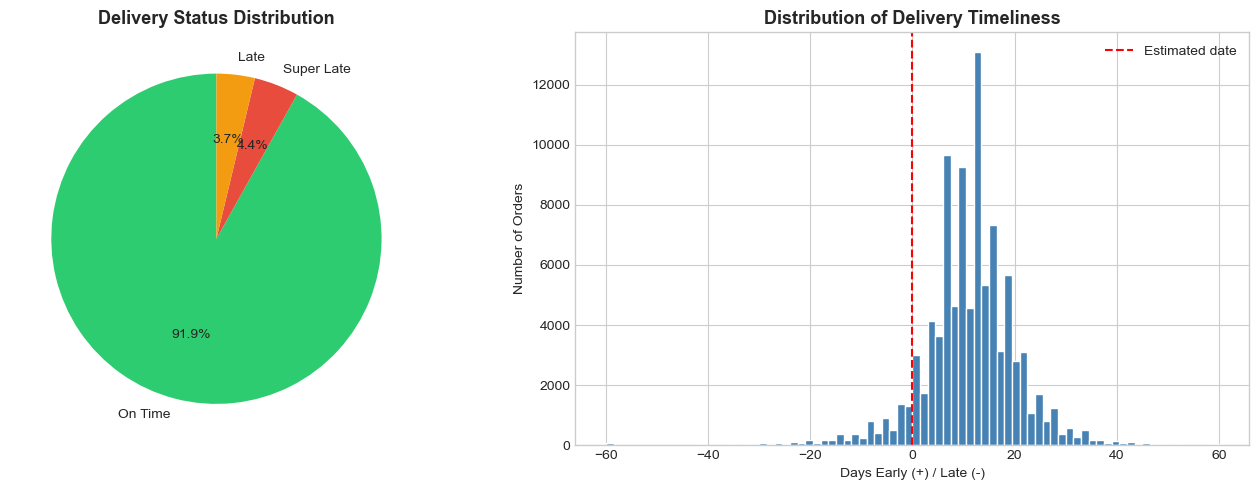

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
color_map = {'On Time': '#2ecc71', 'Late': '#f39c12', 'Super Late': '#e74c3c'}
status_counts = delivered['delivery_status'].value_counts()
axes[0].pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=[color_map[s] for s in status_counts.index],
    startangle=90
)
axes[0].set_title('Delivery Status Distribution', fontsize=13, fontweight='bold')

# Histogram of days_difference
axes[1].hist(delivered['days_difference'].clip(-60, 60), bins=80, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Estimated date')
axes[1].set_xlabel('Days Early (+) / Late (-)')
axes[1].set_ylabel('Number of Orders')
axes[1].set_title('Distribution of Delivery Timeliness', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('delivery_status_overview.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Story 3: The Geographic Heatmap
Which Brazilian states have the highest percentage of late deliveries?

In [10]:
state_stats = (
    delivered
    .groupby('customer_state')
    .agg(
        total_orders  = ('order_id', 'count'),
        late_orders   = ('delivery_status', lambda x: (x != 'On Time').sum()),
        avg_review    = ('review_score', 'mean'),
        avg_days_diff = ('days_difference', 'mean'),
    )
    .reset_index()
)
state_stats['late_pct'] = (state_stats['late_orders'] / state_stats['total_orders'] * 100).round(1)
state_stats = state_stats.sort_values('late_pct', ascending=False)

print('Top 5 worst states for late deliveries:')
display(state_stats[['customer_state', 'total_orders', 'late_pct', 'avg_review']].head())

Top 5 worst states for late deliveries:


,customer_state,total_orders,late_pct,avg_review
1,AL,397,23.9,3.847716
9,MA,717,19.7,3.832865
16,PI,476,16.0,3.993631
5,CE,1279,15.3,3.944226
24,SE,335,15.2,3.907186


In [11]:
fig = px.bar(
    state_stats,
    x='customer_state', y='late_pct',
    color='late_pct',
    color_continuous_scale='RdYlGn_r',
    title='% Late Deliveries by Brazilian State',
    labels={'customer_state': 'State', 'late_pct': '% Late Orders'},
    text=state_stats['late_pct'].astype(str) + '%',
    hover_data={'avg_review': ':.2f', 'total_orders': True},
)
fig.update_traces(textposition='outside')
fig.update_layout(
    coloraxis_showscale=False,
    xaxis_tickangle=-45,
    height=500,
)
fig.show()

In [12]:
# Scatter: Is average review score lower in states with more late deliveries?
fig = px.scatter(
    state_stats,
    x='late_pct', y='avg_review',
    size='total_orders',
    text='customer_state',
    title='Late Delivery Rate vs Average Review Score by State',
    labels={'late_pct': '% Late Orders', 'avg_review': 'Avg Review Score (1-5)'},
    color='late_pct',
    color_continuous_scale='RdYlGn_r',
)
fig.update_traces(textposition='top center')
fig.update_layout(coloraxis_showscale=False)
fig.show()

---
## Story 4: The Sentiment Correlation
Do late deliveries actually cause bad reviews?

In [13]:
# Average review score by delivery status
sentiment = delivered.groupby('delivery_status')['review_score'].mean().reset_index()
sentiment.columns = ['Delivery Status', 'Avg Review Score']

color_map = {'On Time': '#2ecc71', 'Late': '#f39c12', 'Super Late': '#e74c3c'}

fig = px.bar(
    sentiment,
    x='Delivery Status', y='Avg Review Score',
    color='Delivery Status',
    color_discrete_map=color_map,
    title='Average Review Score by Delivery Status',
    text=sentiment['Avg Review Score'].round(2),
)
fig.update_traces(textposition='outside')
fig.update_layout(yaxis_range=[0, 5.5], showlegend=False)
fig.show()

In [14]:
# Bin days_difference to show trend more clearly
bins   = [-100, -30, -14, -7, -3, 0, 7, 30, 100]
labels = ['< -30d', '-30 to -14d', '-14 to -7d', '-7 to -3d', '-3 to 0d', '0 to 7d', '7 to 30d', '> 30d']

delivered['days_bin'] = pd.cut(delivered['days_difference'], bins=bins, labels=labels)

bin_scores = (
    delivered
    .groupby('days_bin', observed=True)
    .agg(avg_review=('review_score', 'mean'), count=('order_id', 'count'))
    .reset_index()
)

fig = px.line(
    bin_scores,
    x='days_bin', y='avg_review',
    title='Average Review Score vs Delivery Timeliness',
    labels={'days_bin': 'Days Early (+) / Late (−)', 'avg_review': 'Avg Review Score'},
    markers=True,
    text=bin_scores['avg_review'].round(2),
)
fig.update_traces(textposition='top center')
fig.update_layout(yaxis_range=[1, 5.5])
fig.show()

print('\nOrder counts per bin (for context):')
display(bin_scores[['days_bin', 'count', 'avg_review']].round(2))


Order counts per bin (for context):


,days_bin,count,avg_review
0,< -30d,359,1.84
1,-30 to -14d,1352,1.64
2,-14 to -7d,2013,1.76
3,-7 to -3d,1945,2.67
4,-3 to 0d,3579,4.01
5,0 to 7d,20707,4.22
6,7 to 30d,64427,4.32
7,> 30d,2043,4.26


---
## Bonus: Product Category Translation (Portuguese → English)

In [15]:
# Join order_items → products → translations to get English category names per order
products_en = products.merge(translations, on='product_category_name', how='left')
products_en['category_en'] = (
    products_en['product_category_name_english']
    .fillna(products_en['product_category_name'])  # fallback to Portuguese if no translation
)

# One product per order_item; pick the first product category per order
order_category = (
    order_items
    .merge(products_en[['product_id', 'category_en']], on='product_id', how='left')
    .groupby('order_id')['category_en']
    .first()
    .reset_index()
)

delivered = delivered.merge(order_category, on='order_id', how='left')

print('Sample category translations:')
display(
    products_en[['product_category_name', 'category_en']]
    .drop_duplicates()
    .dropna()
    .head(10)
)

Sample category translations:


,product_category_name,category_en
0,perfumaria,perfumery
1,artes,art
2,esporte_lazer,sports_leisure
3,bebes,baby
4,utilidades_domesticas,housewares
5,instrumentos_musicais,musical_instruments
6,cool_stuff,cool_stuff
7,moveis_decoracao,furniture_decor
8,eletrodomesticos,home_appliances
9,brinquedos,toys


In [16]:
# Late delivery rate by product category (top 15 worst categories)
cat_stats = (
    delivered
    .groupby('category_en')
    .agg(
        total      = ('order_id', 'count'),
        late       = ('delivery_status', lambda x: (x != 'On Time').sum()),
        avg_review = ('review_score', 'mean'),
    )
    .reset_index()
)
cat_stats['late_pct'] = (cat_stats['late'] / cat_stats['total'] * 100).round(1)
cat_stats = cat_stats[cat_stats['total'] >= 100].sort_values('late_pct', ascending=False)

fig = px.bar(
    cat_stats.head(15),
    x='late_pct', y='category_en',
    orientation='h',
    color='late_pct',
    color_continuous_scale='RdYlGn_r',
    title='Top 15 Product Categories by Late Delivery Rate',
    labels={'late_pct': '% Late', 'category_en': 'Category'},
    text=cat_stats.head(15)['late_pct'].astype(str) + '%',
)
fig.update_traces(textposition='outside')
fig.update_layout(coloraxis_showscale=False, yaxis={'categoryorder': 'total ascending'})
fig.show()

---
## Candidate's Choice: Monthly Performance Trend

**Business Justification:** A snapshot metric tells the CEO *how bad* the problem is today.  
A monthly trend tells her *whether it is getting worse* — which determines urgency.  
If late-delivery rates spiked after a warehouse move or Black Friday, the fix is very different  
from a slow structural decline in logistics network capacity.

In [17]:
delivered['order_month'] = delivered['order_purchase_timestamp'].dt.to_period('M').astype(str)

monthly = (
    delivered
    .groupby('order_month')
    .agg(
        total      = ('order_id', 'count'),
        late       = ('delivery_status', lambda x: (x != 'On Time').sum()),
        avg_review = ('review_score', 'mean'),
    )
    .reset_index()
)
monthly['late_pct'] = (monthly['late'] / monthly['total'] * 100).round(1)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=monthly['order_month'], y=monthly['late_pct'],
    name='% Late', mode='lines+markers', line=dict(color='crimson', width=2),
))
fig.add_trace(go.Scatter(
    x=monthly['order_month'], y=monthly['avg_review'],
    name='Avg Review', mode='lines+markers', line=dict(color='steelblue', width=2),
    yaxis='y2',
))
fig.update_layout(
    title='Monthly Late Delivery Rate vs Average Review Score',
    xaxis_title='Month',
    yaxis=dict(title='% Late Deliveries', titlefont=dict(color='crimson')),
    yaxis2=dict(title='Avg Review Score', titlefont=dict(color='steelblue'),
                overlaying='y', side='right', range=[1, 5]),
    legend=dict(x=0.01, y=0.99),
    height=450,
)
fig.show()

---
## Export Master Dataset for Streamlit Dashboard

In [18]:
export_cols = [
    'order_id',
    'customer_state',
    'customer_city',
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'days_difference',
    'delivery_status',
    'review_score',
    'category_en',
]

master_export = delivered[export_cols].copy()

# Convert timestamps to string for clean CSV output
for col in ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']:
    master_export[col] = master_export[col].astype(str)

master_export.to_csv('master_dataset.csv', index=False)
print(f'Exported {len(master_export):,} rows → master_dataset.csv')
print('   Download this file and place it in your dashboard/data/ folder.')

# Download the file in Colab
# from google.colab import files
# files.download('master_dataset.csv')

Exported 96,470 rows → master_dataset.csv
   Download this file and place it in your dashboard/data/ folder.
